# SARIMAX Model — Solar Irradiance Forecasting
---
| | |
|---|---|
| **Thesis Title** | A Machine Learning Approach to Solar Irradiance Prediction Using Historical Weather Data |
| **Programme** | B.Sc. Internet Informatics |
| **Institution** | Kaunas University of Technology |
| **Notebook** | 04 — SARIMAX Model |
| **Target Variable** | Global Horizontal Irradiance — GHI (W/m²) |

---
### Notebook Objectives
1. Load the pre-built SARIMAX train/test splits from `03_train_test_split.ipynb`
2. Verify stationarity of the target series and inspect ACF/PACF
3. Select SARIMA orders using `auto_arima` (constrained search, m=24)
4. Fit a `SARIMAX` model with exogenous regressors on the training set
5. Diagnose residuals (Ljung-Box, normality, heteroscedasticity)
6. Generate one-step-ahead and dynamic forecasts on the test set
7. Evaluate against a persistence baseline (GHI[t−24])
8. Export predictions and summary metrics

## Table of Contents
1. [Setup and Data Loading](#setup)
3. [Stationarity & ACF/PACF](#stationary)
4. [Order Selection](#order)


---
<a id="setup"></a>
## 1. Setup and Data Loading

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


### 1.1. Loading the data

In [5]:
y_train = pd.read_csv('../data/sarimax_y_train.csv', index_col='Date Time', parse_dates=True).squeeze()
y_test  = pd.read_csv('../data/sarimax_y_test.csv',  index_col='Date Time', parse_dates=True).squeeze()

X_train = pd.read_csv('../data/sarimax_X_train.csv', index_col='Date Time', parse_dates=True)
X_test  = pd.read_csv('../data/sarimax_X_test.csv',  index_col='Date Time', parse_dates=True)

print('Train:')
print(f'  y_train : {y_train.shape}  |  {y_train.index.min().date()} → {y_train.index.max().date()}')
print(f'  X_train : {X_train.shape}')
print('Test:')
print(f'  y_test  : {y_test.shape}   |  {y_test.index.min().date()} → {y_test.index.max().date()}')
print(f'  X_test  : {X_test.shape}')
print(f'\nFeatures : {list(X_train.columns)}')

Train:
  y_train : (7295,)  |  2022-01-01 → 2022-10-31
  X_train : (7295, 13)
Test:
  y_test  : (1464,)   |  2022-11-01 → 2022-12-31
  X_test  : (1464, 13)

Features : ['hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'kt_ghi', 'diffuse_fraction', 'Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitable Water', 'Cloud Type', 'cos_zenith_x_clearsky', 'temp_x_humidity']


In [7]:
checks_passed = True

if y_train.isnull().sum() > 0:
    print("Warning: NaNs in y_train")
    checks_passed = False

if y_test.isnull().sum() > 0:
    print("Warning: NaNs in y_test")
    checks_passed = False

if X_train.isnull().sum().sum() > 0:
    print("Warning: NaNs in X_train")
    checks_passed = False

if X_test.isnull().sum().sum() > 0:
    print("Warning: NaNs in X_test")
    checks_passed = False

if y_train.index.max() >= y_test.index.min():
    print("Warning: Data leakage! train/test dates overlap.")
    checks_passed = False

if checks_passed:
    print("All sanity checks passed successfully.")
else:
    print("Some sanity checks failed. Please review the warnings above.")

All sanity checks passed successfully.


---
<a id="stationary"></a>
## 2. Stationarity & ACF/PACF

SARIMAX requires the target series to be (weakly) stationary after differencing. GHI has a strong diurnal cycle (period = 24 h) so we expect seasonal non-stationarity that seasonal differencing (lag 24) should resolve.

Two complementary tests are used:
- **ADF** (Augmented Dickey-Fuller) — H₀: unit root present (non-stationary). Reject H₀ → stationary.
- **KPSS** — H₀: series is stationary. Reject H₀ → non-stationary.

For stationarity to be confirmed, ADF should reject H₀ **and** KPSS should fail to reject H₀.

In [9]:
def stationarity_report(series, label):
    """Run ADF and KPSS tests and print a compact summary."""
    adf_stat, adf_p, _, _, adf_cv, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_cv    = kpss(series.dropna(), regression='c', nlags='auto')

    adf_result  = 'STATIONARY'     if adf_p  < 0.05 else 'NON-STATIONARY'
    kpss_result = 'NON-STATIONARY' if kpss_p < 0.05 else 'STATIONARY'

    print(f'\n--- {label} ---')
    print(f'  ADF  stat={adf_stat:.4f}   p={adf_p:.4f}   → {adf_result}')
    print(f'  KPSS stat={kpss_stat:.4f}  p={kpss_p:.4f}   → {kpss_result}')

# Raw series
stationarity_report(y_train, 'GHI — raw')

# After seasonal differencing (lag 24)
y_sdiff = y_train.diff(24).dropna()
stationarity_report(y_sdiff, 'GHI — seasonal diff (lag 24)')

# After seasonal + first-order differencing
y_sdiff1 = y_sdiff.diff(1).dropna()
stationarity_report(y_sdiff1, 'GHI — seasonal diff + first diff')


--- GHI — raw ---
  ADF  stat=-5.9027   p=0.0000   → STATIONARY
  KPSS stat=4.9804  p=0.0100   → NON-STATIONARY

--- GHI — seasonal diff (lag 24) ---
  ADF  stat=-19.2989   p=0.0000   → STATIONARY
  KPSS stat=0.0402  p=0.1000   → STATIONARY

--- GHI — seasonal diff + first diff ---
  ADF  stat=-24.8562   p=0.0000   → STATIONARY
  KPSS stat=0.0136  p=0.1000   → STATIONARY


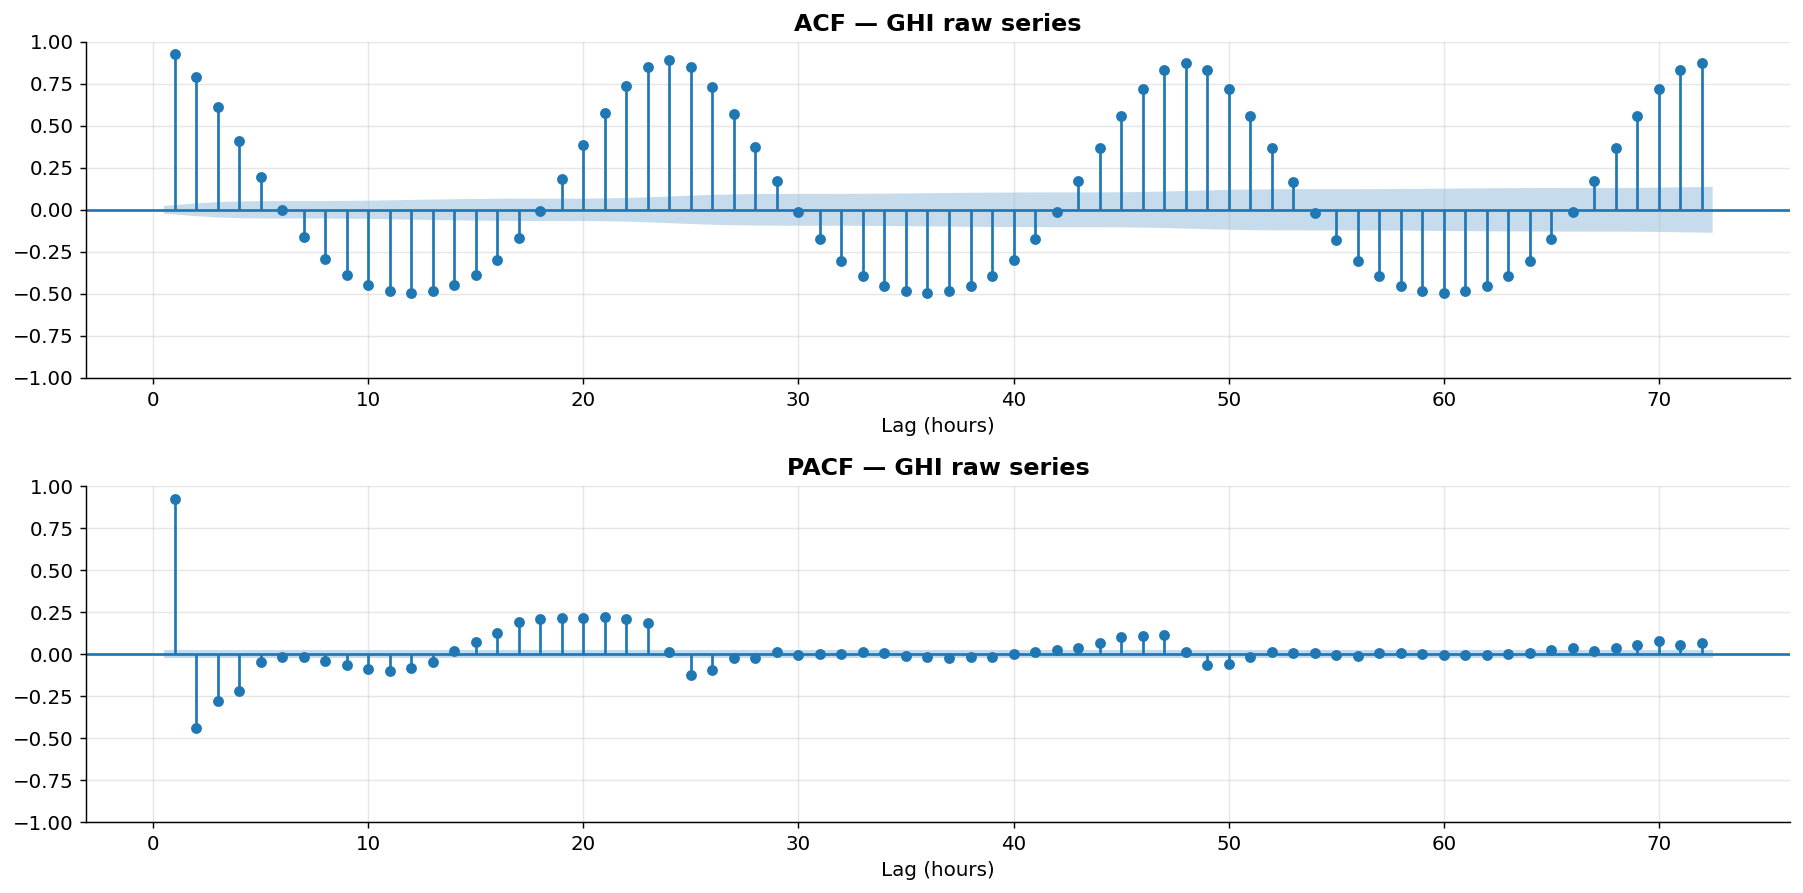

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(y_train, lags=72, alpha=0.05, ax=axes[0], zero=False)
axes[0].set_title('ACF — GHI raw series', fontweight='bold')
axes[0].set_xlabel('Lag (hours)')

plot_pacf(y_train, lags=72, alpha=0.05, method='ywm', ax=axes[1], zero=False)
axes[1].set_title('PACF — GHI raw series', fontweight='bold')
axes[1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.savefig('../outputs/figures/sarimax_acf_pacf_raw.png', bbox_inches='tight')
plt.show()

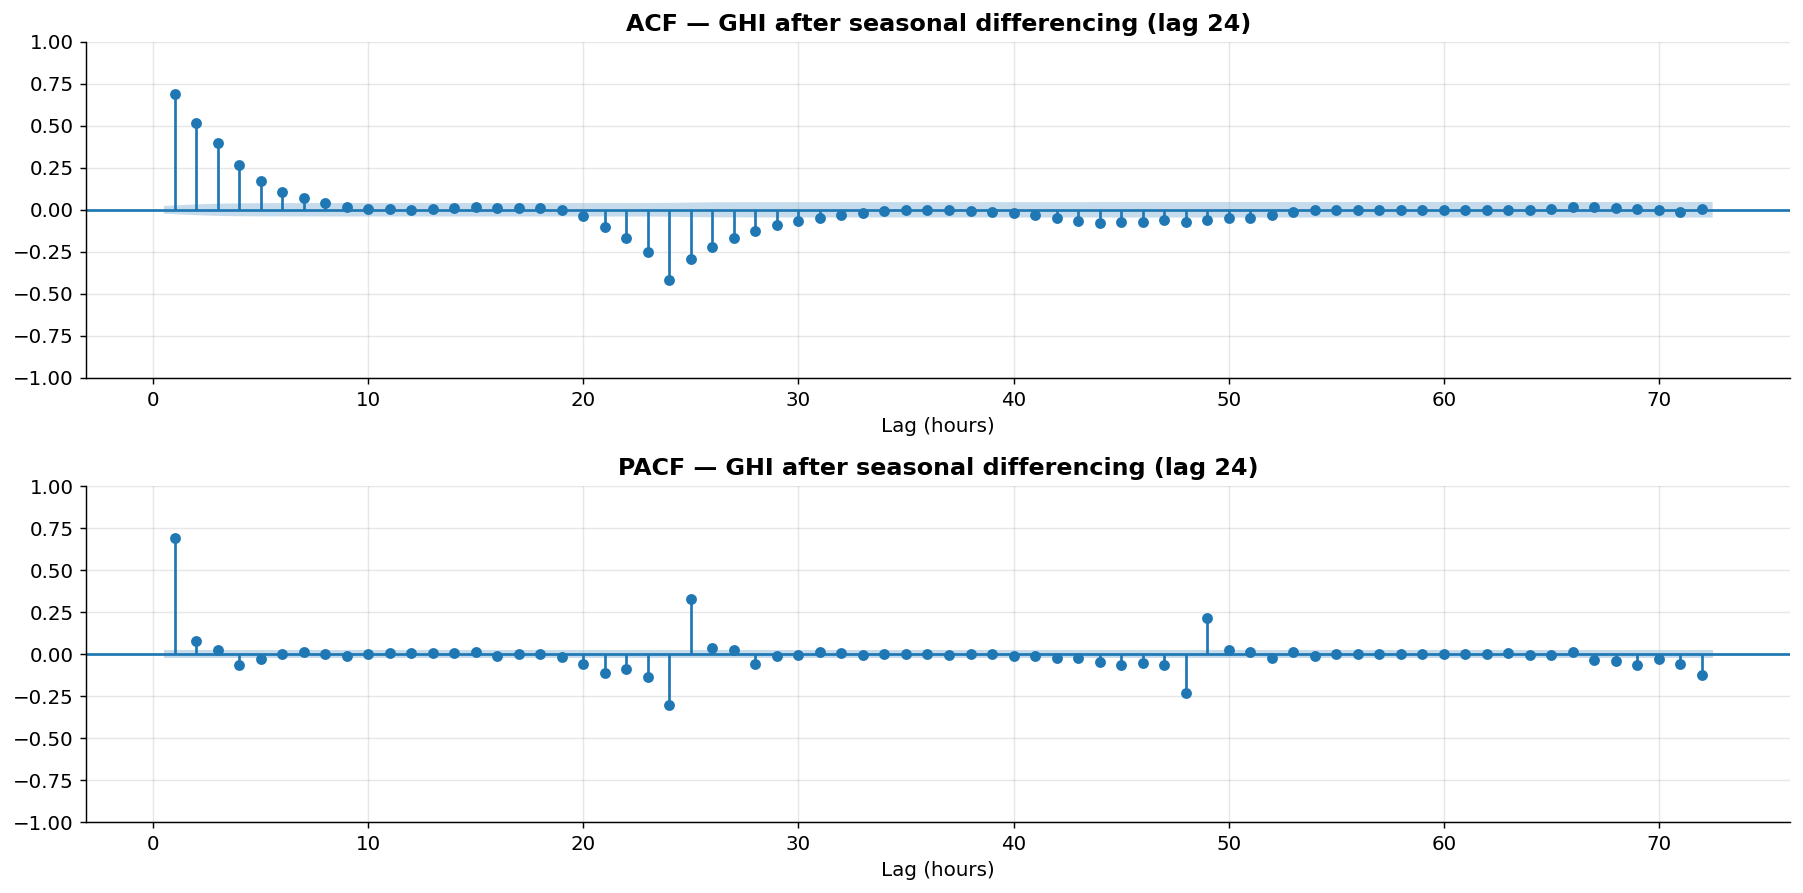

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(y_sdiff, lags=72, alpha=0.05, ax=axes[0], zero=False)
axes[0].set_title('ACF — GHI after seasonal differencing (lag 24)', fontweight='bold')
axes[0].set_xlabel('Lag (hours)')

plot_pacf(y_sdiff, lags=72, alpha=0.05, method='ywm', ax=axes[1], zero=False)
axes[1].set_title('PACF — GHI after seasonal differencing (lag 24)', fontweight='bold')
axes[1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.savefig('../outputs/figures/sarimax_acf_pacf.png', bbox_inches='tight')
plt.show()


A large spike at lag 24 (and its multiples) confirms strong diurnal seasonality. This motivates D=1 seasonal differencing before fitting SARIMAX.

---
<a id="order"></a>
## 4. Order Selection

`auto_arima` from `pmdarima` performs a stepwise search over ARIMA order combinations, selecting the model with the lowest **AIC**.|

In [16]:
ORDER          = (1, 0, 1)    # (p, d, q)
SEASONAL_ORDER = (1, 1, 1, 24) # (P, D, Q, m)

print(f'ARIMA order         : {ORDER}')
print(f'Seasonal order      : {SEASONAL_ORDER}')
print(f'Exogenous features  : {list(X_train.columns)}')

ARIMA order         : (1, 0, 1)
Seasonal order      : (1, 1, 1, 24)
Exogenous features  : ['hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'kt_ghi', 'diffuse_fraction', 'Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitable Water', 'Cloud Type', 'cos_zenith_x_clearsky', 'temp_x_humidity']


---
<a id="fit"></a>
## 5. Model Fitting

The model is re-fit using `statsmodels.SARIMAX` for full control over the estimation and forecast API.

`concentrate_scale=True` concentrates the variance parameter out of the likelihood, speeding up optimisation without affecting point forecasts.

In [18]:
sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=True,
    enforce_invertibility=True,
    concentrate_scale=True
)

print('Fitting SARIMAX...')
fit = sarimax_model.fit(disp=False)
print(fit.summary())

Fitting SARIMAX...
                                     SARIMAX Results                                      
Dep. Variable:                                GHI   No. Observations:                 7295
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -37997.164
Date:                            Fri, 17 Apr 2026   AIC                          76030.328
Time:                                    11:27:37   BIC                          76154.378
Sample:                                01-01-2022   HQIC                         76072.992
                                     - 10-31-2022   Scale                         2017.610
Covariance Type:                              opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
hour_sin              -4.514e-07   1.95e-06     -0.231      0.817   -4.28